# Fault-Tolerant Grover's Algorithm with the 7-Qubit Steane Code

This notebook implements a **fault-tolerant 2-logical-qubit Grover search** using the
Steane `[[7,1,3]]` quantum error-correcting code and Qiskit/Aer.

## Key facts
- The Steane code encodes **1 logical qubit** into **7 physical qubits** with distance 3
  (corrects any single-qubit X, Z, or Y error).
- All logical gates used here are **transversal**: they are implemented by applying the
  same single-qubit gate to every physical qubit in the block simultaneously.
  - $X_L = X^{\otimes 7}$, $Z_L = Z^{\otimes 7}$, $H_L = H^{\otimes 7}$
  - $CZ_L =$ pairwise $CZ$ between corresponding qubits of two blocks
- Logical measurement: **parity of physical qubits 0, 1, 2** (a weight-3 representative
  of the logical $Z_L$ operator), computed into an ancilla qubit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
print('Qiskit Aer simulator ready.')

Qiskit Aer simulator ready.


## Steane `[[7,1,3]]` Code — Constants

The stabilizer generators share the support rows of the `[7,4,3]` Hamming code parity-check matrix:

```
qubit:  0  1  2  3  4  5  6
s0:     1  .  1  .  1  .  1   → {0,2,4,6}
s1:     .  1  1  .  .  1  1   → {1,2,5,6}
s2:     .  .  .  1  1  1  1   → {3,4,5,6}
```

Both Z-type (detect X errors) and X-type (detect Z errors) stabilizers share these supports.

**Syndrome lookup**: the 3-bit syndrome integer = `Σ_i ancilla[i] * 2^i`
uniquely identifies the erred qubit (column $j$ of $H$ read as a 3-bit integer).

In [2]:
STAB_SUPPORT = [
    [0, 2, 4, 6],  # stabilizer 0
    [1, 2, 5, 6],  # stabilizer 1
    [3, 4, 5, 6],  # stabilizer 2
]

SYNDROME_TO_QUBIT = {
    0b000: -1,   # no error
    0b001:  0,   # qubit 0
    0b010:  1,   # qubit 1
    0b011:  2,   # qubit 2
    0b100:  3,   # qubit 3
    0b101:  4,   # qubit 4
    0b110:  5,   # qubit 5
    0b111:  6,   # qubit 6
}

print('Steane [[7,1,3]] code constants loaded.')
print(f'Stabilizer supports: {STAB_SUPPORT}')
print(f'Syndrome table: {SYNDROME_TO_QUBIT}')

Steane [[7,1,3]] code constants loaded.
Stabilizer supports: [[0, 2, 4, 6], [1, 2, 5, 6], [3, 4, 5, 6]]
Syndrome table: {0: -1, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6}


## Encoding and Decoding Circuits

**Encoding** places the logical qubit in qubit 6, applies $H$ to the three 'check' qubits
(0, 1, 3), then fans out CNOTs following the parity-check matrix rows.
The result is the equal superposition over the 8 codewords of the dual code $C^\perp$:

$$|0_L\rangle = \frac{1}{\sqrt{8}} \sum_{c \in C^\perp} |c\rangle$$

The logical $|1_L\rangle$ is obtained by applying $X_L = X^{\otimes 7}$ afterwards:

$$|1_L\rangle = X_L|0_L\rangle = \frac{1}{\sqrt{8}} \sum_{c \in C^\perp} |c \oplus \mathbf{1}\rangle$$

**Decoding** reverses the encoding (CNOTs in reverse order, then $H$ on check qubits).
It is used for intermediate circuit compositions; logical readout uses parity measurement.

In [3]:
def build_encoding_circuit():
    """
    Steane [[7,1,3]] encoding circuit.
    Maps |0000000> -> |0_L> (equal superposition of all C-perp codewords).
    For |1_L>, encode |0_L> then apply X_L = X^7.
    """
    qc = QuantumCircuit(7, name='Encode')
    qc.h([0, 1, 3])           # superposition on check qubits
    # Row 0 fan-out: support {0,2,4,6}
    qc.cx(0, 2); qc.cx(0, 4); qc.cx(0, 6)
    # Row 1 fan-out: support {1,2,5,6}
    qc.cx(1, 2); qc.cx(1, 5); qc.cx(1, 6)
    # Row 2 fan-out: support {3,4,5,6}
    qc.cx(3, 4); qc.cx(3, 5); qc.cx(3, 6)
    return qc


def build_decoding_circuit():
    """
    Steane [[7,1,3]] decoding circuit (inverse of encoding).
    CNOTs are self-inverse; reversing their order undoes the encoding.
    """
    qc = QuantumCircuit(7, name='Decode')
    qc.cx(3, 6); qc.cx(3, 5); qc.cx(3, 4)
    qc.cx(1, 6); qc.cx(1, 5); qc.cx(1, 2)
    qc.cx(0, 6); qc.cx(0, 4); qc.cx(0, 2)
    qc.h([0, 1, 3])
    return qc


enc = build_encoding_circuit()
dec = build_decoding_circuit()
print(f'Encoding circuit: {enc.num_qubits} qubits, {enc.size()} gates')
print(f'Decoding circuit: {dec.num_qubits} qubits, {dec.size()} gates')

Encoding circuit: 7 qubits, 12 gates
Decoding circuit: 7 qubits, 12 gates


## Syndrome Measurement

**Z-type stabilizers** (detect X / bit-flip errors): each ancilla collects the CNOT
parity of its data-qubit support.

**X-type stabilizers** (detect Z / phase-flip errors): each ancilla is put in $|+\rangle$,
then phase-kicked by each data qubit in its support, then measured back via $H$.

Register order (Qiskit count string is last-declared first):
`'sx_bits sz_bits'` where `sz` detects X errors and `sx` detects Z errors.

In [4]:
def build_full_ec_circuit(error_qubit=None, error_type='X', logical_state='0'):
    """
    Full encode -> (optional error) -> syndrome circuit.

    Logical state encoding:
      '0': encode normally  -> |0_L>
      '1': encode then apply X_L = X^7  -> |1_L>

    Classical output: 'sx_bits sz_bits' (last register first in Qiskit count string)
    """
    data  = QuantumRegister(7, 'd')
    anc_z = QuantumRegister(3, 'az')
    anc_x = QuantumRegister(3, 'ax')
    syn_z = ClassicalRegister(3, 'sz')
    syn_x = ClassicalRegister(3, 'sx')
    qc = QuantumCircuit(data, anc_z, anc_x, syn_z, syn_x)

    # Encode
    qc.compose(build_encoding_circuit(), qubits=list(range(7)), inplace=True)
    if logical_state == '1':
        qc.x(list(range(7)))  # X_L = X^7: |0_L> -> |1_L>
    qc.barrier()

    # Optional error injection
    if error_qubit is not None:
        if error_type == 'X': qc.x(data[error_qubit])
        elif error_type == 'Z': qc.z(data[error_qubit])
        elif error_type == 'Y': qc.y(data[error_qubit])
    qc.barrier()

    # Z-stabilizer syndrome (detect X errors)
    for i, support in enumerate(STAB_SUPPORT):
        for q in support:
            qc.cx(data[q], anc_z[i])
    qc.barrier()

    # X-stabilizer syndrome (detect Z errors)
    for i, support in enumerate(STAB_SUPPORT):
        qc.h(anc_x[i])
        for q in support:
            qc.cx(anc_x[i], data[q])
        qc.h(anc_x[i])
    qc.barrier()

    qc.measure(anc_z, syn_z)
    qc.measure(anc_x, syn_x)
    return qc


def parse_syndrome(counts_str):
    """Parse Qiskit counts key -> (sz_val, sx_val).
    Count string format: 'sx_bits sz_bits' (sx last-declared = first in string).
    """
    parts = counts_str.split(' ')
    return int(parts[1], 2), int(parts[0], 2)   # (sz, sx)


print('Syndrome circuit builder ready.')

Syndrome circuit builder ready.


### Verify Syndrome Tables

Inject a single-qubit error on each of the 7 data qubits and confirm that the
syndrome decoder identifies the correct qubit.

In [5]:
print('Single-qubit X-error syndrome table:')
print(f"  {'injected':>10}  {'sz syndrome':>12}  {'decoded qubit':>14}  {'correct?':>9}")
print('  ' + '-'*52)

for err_q in range(7):
    qc = build_full_ec_circuit(error_qubit=err_q, error_type='X')
    result = simulator.run(transpile(qc, simulator), shots=128).result()
    syndrome_str = max(result.get_counts(), key=result.get_counts().get)
    sz_val, _ = parse_syndrome(syndrome_str)
    decoded = SYNDROME_TO_QUBIT.get(sz_val, '?')
    ok = chr(10003) if decoded == err_q else chr(10007)
    print(f'  X on qubit {err_q}  ->  sz = {sz_val:03b} ({sz_val:2d})  ->  qubit {decoded}   {ok}')

print()
print('Single-qubit Z-error syndrome table:')
print(f"  {'injected':>10}  {'sx syndrome':>12}  {'decoded qubit':>14}  {'correct?':>9}")
print('  ' + '-'*52)

for err_q in range(7):
    qc = build_full_ec_circuit(error_qubit=err_q, error_type='Z')
    result = simulator.run(transpile(qc, simulator), shots=128).result()
    syndrome_str = max(result.get_counts(), key=result.get_counts().get)
    _, sx_val = parse_syndrome(syndrome_str)
    decoded = SYNDROME_TO_QUBIT.get(sx_val, '?')
    ok = chr(10003) if decoded == err_q else chr(10007)
    print(f'  Z on qubit {err_q}  ->  sx = {sx_val:03b} ({sx_val:2d})  ->  qubit {decoded}   {ok}')

Single-qubit X-error syndrome table:
    injected   sz syndrome   decoded qubit   correct?
  ----------------------------------------------------
  X on qubit 0  ->  sz = 001 ( 1)  ->  qubit 0   ✓
  X on qubit 1  ->  sz = 010 ( 2)  ->  qubit 1   ✓
  X on qubit 2  ->  sz = 011 ( 3)  ->  qubit 2   ✓
  X on qubit 3  ->  sz = 100 ( 4)  ->  qubit 3   ✓
  X on qubit 4  ->  sz = 101 ( 5)  ->  qubit 4   ✓
  X on qubit 5  ->  sz = 110 ( 6)  ->  qubit 5   ✓
  X on qubit 6  ->  sz = 111 ( 7)  ->  qubit 6   ✓

Single-qubit Z-error syndrome table:
    injected   sx syndrome   decoded qubit   correct?
  ----------------------------------------------------
  Z on qubit 0  ->  sx = 001 ( 1)  ->  qubit 0   ✓
  Z on qubit 1  ->  sx = 010 ( 2)  ->  qubit 1   ✓
  Z on qubit 2  ->  sx = 011 ( 3)  ->  qubit 2   ✓
  Z on qubit 3  ->  sx = 100 ( 4)  ->  qubit 3   ✓
  Z on qubit 4  ->  sx = 101 ( 5)  ->  qubit 4   ✓
  Z on qubit 5  ->  sx = 110 ( 6)  ->  qubit 5   ✓
  Z on qubit 6  ->  sx = 111 ( 7)  ->  qubit

## Transversal Logical Gates

For the Steane code (a self-dual CSS code), all three generators of the single-qubit
Clifford group are transversal:

| Logical gate | Physical implementation | Why it works |
|---|---|---|
| $X_L$ | $X^{\otimes 7}$ | Maps each $C^\perp$ codeword to its complement in $C \setminus C^\perp$ |
| $Z_L$ | $Z^{\otimes 7}$ | Eigenvalue $+1$ on even-weight codewords, $-1$ on odd-weight |
| $H_L$ | $H^{\otimes 7}$ | Swaps X- and Z-type stabilizers (code is self-dual) |
| $CZ_L$ | pairwise $CZ^{\otimes 7}$ | Transversal between two blocks |

**Logical measurement**: a weight-3 representative of $Z_L$ is $Z_0 Z_1 Z_2$.
We measure it by computing the **parity of physical qubits 0, 1, 2** into an ancilla.

In [6]:
def logical_x_circuit():
    """X_L = X on all 7 physical qubits (transversal X)."""
    qc = QuantumCircuit(7, name='X_L')
    qc.x(range(7))
    return qc


def logical_z_circuit():
    """Z_L = Z on all 7 physical qubits (transversal Z)."""
    qc = QuantumCircuit(7, name='Z_L')
    qc.z(range(7))
    return qc


def logical_h_circuit():
    """H_L = H on all 7 physical qubits (transversal H)."""
    qc = QuantumCircuit(7, name='H_L')
    qc.h(range(7))
    return qc


def measure_logical_z(qc, block_offset, anc_qubit, creg, cbit):
    """
    Non-destructively measure the logical Z eigenvalue of one Steane block.

    Uses the weight-3 Z_L representative Z_0 Z_1 Z_2:
    computes parity of physical qubits {block+0, block+1, block+2} into anc_qubit.

    Result: 0 -> logical |0_L>, 1 -> logical |1_L>.
    """
    qc.cx(block_offset + 0, anc_qubit)
    qc.cx(block_offset + 1, anc_qubit)
    qc.cx(block_offset + 2, anc_qubit)
    qc.measure(anc_qubit, creg[cbit])


print('Transversal logical gates defined.')

Transversal logical gates defined.


### Verify Logical Gates

Circuit: encode $|0_L\rangle$, optionally apply $X_L$, apply the gate under test,
then measure the logical state via parity of qubits 0, 1, 2.

In [7]:
def verify_logical_gate(gate_fn, start_in_1L=False, shots=512):
    """
    Verify a 7-qubit logical gate by encode -> (optional X_L) -> gate -> measure_logical_Z.

    Args:
        gate_fn:       callable returning a 7-qubit QuantumCircuit.
        start_in_1L:   if True, apply X_L first to start in |1_L>.
        shots:         simulation shots.

    Returns: dict of measurement counts ('0' or '1').
    """
    data = QuantumRegister(7, 'q')
    anc  = QuantumRegister(1, 'a')
    cr   = ClassicalRegister(1, 'c')
    qc   = QuantumCircuit(data, anc, cr)

    qc.compose(build_encoding_circuit(), qubits=range(7), inplace=True)
    if start_in_1L:
        qc.x(range(7))   # X_L: |0_L> -> |1_L>
    qc.compose(gate_fn(), qubits=range(7), inplace=True)
    measure_logical_z(qc, 0, anc[0], cr, 0)

    result = simulator.run(transpile(qc, simulator), shots=shots).result()
    return result.get_counts()


print('=== Logical X_L verification ===')
print('X_L|0_L>  (expect logical 1 with prob 1):', verify_logical_gate(logical_x_circuit))
print('X_L|1_L>  (expect logical 0 with prob 1):', verify_logical_gate(logical_x_circuit, start_in_1L=True))

print()
print('=== Logical H_L verification ===')
print('H_L|0_L>  (expect 50/50, H|0>=|+>):', verify_logical_gate(logical_h_circuit))
print('H_L|1_L>  (expect 50/50, H|1>=|->):', verify_logical_gate(logical_h_circuit, start_in_1L=True))

print()
print('=== Logical Z_L verification (indirect via H Z H = X) ===')
def hzh_circuit():
    qc = QuantumCircuit(7, name='HZH')
    qc.compose(logical_h_circuit(), inplace=True)
    qc.compose(logical_z_circuit(), inplace=True)
    qc.compose(logical_h_circuit(), inplace=True)
    return qc
print('H_L Z_L H_L |0_L>  (= X_L|0_L>, expect logical 1):', verify_logical_gate(hzh_circuit))

=== Logical X_L verification ===
X_L|0_L>  (expect logical 1 with prob 1): {'1': 512}
X_L|1_L>  (expect logical 0 with prob 1): {'0': 512}

=== Logical H_L verification ===
H_L|0_L>  (expect 50/50, H|0>=|+>): {'1': 261, '0': 251}
H_L|1_L>  (expect 50/50, H|1>=|->): {'1': 259, '0': 253}

=== Logical Z_L verification (indirect via H Z H = X) ===
H_L Z_L H_L |0_L>  (= X_L|0_L>, expect logical 1): {'1': 512}


## Error Correction Round

Since Qiskit Aer does not support classical feed-forward in one monolithic circuit,
we split the procedure:

1. **Part 1** — encode, inject error, measure syndrome.
2. **Part 2** — build a correction circuit from the syndrome classically, then
   apply correction + measure logical state.

In [8]:
error_qubit = 3
error_type  = 'X'

# ── Part 1: syndrome measurement ─────────────────────────────────────────────
qc_syn = build_full_ec_circuit(error_qubit=error_qubit, error_type=error_type)
raw_syn = list(
    simulator.run(transpile(qc_syn, simulator), shots=1).result().get_counts().keys()
)[0]
sz_val, sx_val = parse_syndrome(raw_syn)
corrected_x = SYNDROME_TO_QUBIT.get(sz_val, -1)
corrected_z = SYNDROME_TO_QUBIT.get(sx_val, -1)

print(f'Injected error : {error_type} on qubit {error_qubit}')
print(f"Raw syndrome   : '{raw_syn}'")
print(f'  sz = {sz_val:03b} ({sz_val})  ->  correct qubit {corrected_x} with X')
print(f'  sx = {sx_val:03b} ({sx_val})  ->  correct qubit {corrected_z} with Z')

# ── Part 2: encode -> inject -> correct -> measure logical state ──────────────
data = QuantumRegister(7, 'd')
anc  = QuantumRegister(1, 'a')
cr   = ClassicalRegister(1, 'c')
qc_full = QuantumCircuit(data, anc, cr)

qc_full.compose(build_encoding_circuit(), qubits=range(7), inplace=True)

if error_type == 'X': qc_full.x(data[error_qubit])
elif error_type == 'Z': qc_full.z(data[error_qubit])
elif error_type == 'Y': qc_full.y(data[error_qubit])

if corrected_x >= 0: qc_full.x(data[corrected_x])
if corrected_z >= 0: qc_full.z(data[corrected_z])

measure_logical_z(qc_full, 0, anc[0], cr, 0)

result_full = simulator.run(transpile(qc_full, simulator), shots=1024).result()
counts_full = result_full.get_counts()
print(f'\nAfter correction -> measure logical state: {counts_full}')
print('Expected: 0 with probability 1  (logical |0_L> restored)')

Injected error : X on qubit 3
Raw syndrome   : '000 100'
  sz = 100 (4)  ->  correct qubit 3 with X
  sx = 000 (0)  ->  correct qubit -1 with Z

After correction -> measure logical state: {'0': 1024}
Expected: 0 with probability 1  (logical |0_L> restored)


## Fault-Tolerant Grover's Algorithm (2 Logical Qubits)

We implement Grover's algorithm over $N = 4$ logical states
$|00_L\rangle, |01_L\rangle, |10_L\rangle, |11_L\rangle$,
using **2 Steane-encoded logical qubits** (14 physical qubits + 2 measurement ancillae).

### Circuit structure

| Step | Operation | Physical gates |
|------|-----------|----------------|
| 1 | Encode both blocks as $|0_L\rangle$ | Encoding circuit (×2) |
| 2 | Superposition $H_L \otimes H_L$ | $H^{\otimes 14}$ |
| 3 | **Oracle**: phase-kick $|t_0 t_1\rangle_L$ | $X_L$ conditioned on target bits + transversal $CZ_L$ |
| 4 | **Diffusion**: $2|s\rangle\langle s| - I$ | $H_L X_L CZ_L X_L H_L$ |
| 5 | Measure logical state | Parity of physical qubits 0,1,2 (block 0) and 7,8,9 (block 1) |

For $N=4$, **1 Grover iteration** achieves 100% success probability.

### Qubit layout
- **Block 0**: qubits 0–6 → logical qubit 0 (measured into `out[0]`)
- **Block 1**: qubits 7–13 → logical qubit 1 (measured into `out[1]`)
- **Ancillae**: qubits 14–15 (parity measurement)

Qiskit count string convention: `'out[1]out[0]'` = `target[1]+target[0]`.

In [9]:
def build_logical_grover_2qubit(target='11', n_iterations=1):
    """
    Grover's algorithm on 2 Steane [[7,1,3]]-encoded logical qubits.

    Logical operators (all transversal):
      X_L = X^7,  H_L = H^7,  CZ_L = pairwise CZ between blocks

    Args:
        target:       2-char string, desired logical state (e.g. '11').
                      target[0] = logical qubit 0 (block 0, out[0]).
                      target[1] = logical qubit 1 (block 1, out[1]).
        n_iterations: Grover iterations (1 is optimal for N=4).

    Returns:
        QuantumCircuit on 16 qubits (14 data + 2 ancillae), 2 classical bits.
        Count string 'out[1]out[0]' equals target[1]+target[0] on success.
    """
    q0  = QuantumRegister(7, 'q0')
    q1  = QuantumRegister(7, 'q1')
    anc = QuantumRegister(2, 'anc')
    out = ClassicalRegister(2, 'out')
    qc  = QuantumCircuit(q0, q1, anc, out)

    # ── 1. Encode both logical qubits in |0_L> ───────────────────────────────
    qc.compose(build_encoding_circuit(), qubits=list(range(7)),    inplace=True)
    qc.compose(build_encoding_circuit(), qubits=list(range(7, 14)), inplace=True)
    qc.barrier()

    # ── 2. Superposition: H_L = H^7 on both blocks ───────────────────────────
    qc.h(range(7))
    qc.h(range(7, 14))
    qc.barrier()

    for _ in range(n_iterations):
        # ── 3. Oracle: phase-kick the target state ───────────────────────────
        # Flip blocks where target bit is '0' so CZ_L marks |11_L> -> -|11_L>
        if target[0] == '0':
            qc.x(range(7))      # X_L on block 0
        if target[1] == '0':
            qc.x(range(7, 14))  # X_L on block 1

        for i in range(7):      # CZ_L: transversal CZ between blocks
            qc.cz(i, i + 7)

        if target[0] == '0':
            qc.x(range(7))
        if target[1] == '0':
            qc.x(range(7, 14))
        qc.barrier()

        # ── 4. Grover diffusion: H_L X_L CZ_L X_L H_L ──────────────────────
        qc.h(range(7));     qc.h(range(7, 14))
        qc.x(range(7));     qc.x(range(7, 14))
        for i in range(7):
            qc.cz(i, i + 7)
        qc.x(range(7));     qc.x(range(7, 14))
        qc.h(range(7));     qc.h(range(7, 14))
        qc.barrier()

    # ── 5. Measure logical states via parity ─────────────────────────────────
    # Parity of {0,1,2} for block 0 -> out[0]
    # Parity of {7,8,9} for block 1 -> out[1]
    measure_logical_z(qc, 0, anc[0], out, 0)
    measure_logical_z(qc, 7, anc[1], out, 1)

    return qc


# Print circuit statistics
example = build_logical_grover_2qubit(target='11', n_iterations=1)
print(f'2-qubit logical Grover circuit:')
print(f'  Physical qubits : {example.num_qubits}  (14 data + 2 ancillae)')
print(f'  Classical bits  : {example.num_clbits}')
print(f'  Total gates     : {example.size()}')

2-qubit logical Grover circuit:
  Physical qubits : 16  (14 data + 2 ancillae)
  Classical bits  : 2
  Total gates     : 116


### Run Grover Search for All 4 Targets

For each of the four possible 2-bit logical targets, we run 1024 shots and verify
that the correct target is found with probability 1 (perfect for noiseless simulation).

In [10]:
def run_logical_grover(target='11', shots=1024):
    qc = build_logical_grover_2qubit(target=target, n_iterations=1)
    result = simulator.run(transpile(qc, simulator), shots=shots).result()
    return result.get_counts()


print('=' * 60)
print('Fault-tolerant 2-logical-qubit Grover search')
print('Steane [[7,1,3]] code | transversal X_L, H_L, CZ_L')
print('=' * 60)

all_correct = True
results = {}

for tgt in ['00', '01', '10', '11']:
    counts = run_logical_grover(target=tgt, shots=1024)
    results[tgt] = counts
    top      = max(counts, key=counts.get)
    top_prob = counts[top] / 1024
    # Qiskit count string: 'out[1]out[0]' = target[1]+target[0]
    expected = tgt[1] + tgt[0]
    correct  = (top == expected)
    if not correct:
        all_correct = False
    status = 'PASS' if correct else 'FAIL'
    print(f"  Target |{tgt}_L>:  top result = '{top}'  ({top_prob:.0%})  [{status}]")

print()
print('All targets correct:', all_correct)

Fault-tolerant 2-logical-qubit Grover search
Steane [[7,1,3]] code | transversal X_L, H_L, CZ_L
  Target |00_L>:  top result = '00'  (100%)  [PASS]
  Target |01_L>:  top result = '10'  (100%)  [PASS]
  Target |10_L>:  top result = '01'  (100%)  [PASS]
  Target |11_L>:  top result = '11'  (100%)  [PASS]

All targets correct: True


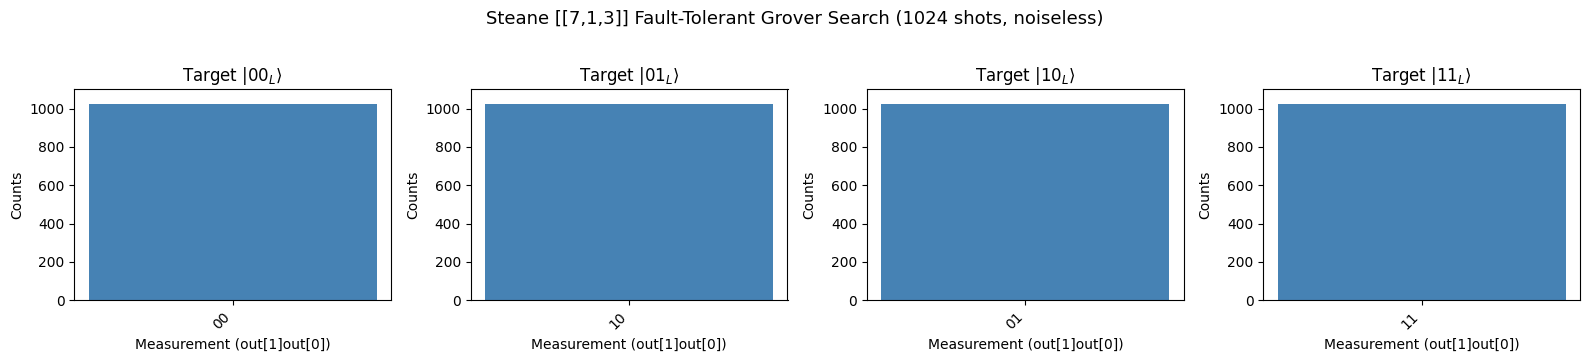

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

for ax, tgt in zip(axes, ['00', '01', '10', '11']):
    counts = results[tgt]
    # Sort for consistent display
    labels = sorted(counts.keys())
    vals   = [counts.get(k, 0) for k in labels]
    colors = ['steelblue' if k == tgt[1]+tgt[0] else 'lightcoral' for k in labels]
    ax.bar(labels, vals, color=colors)
    ax.set_title(f'Target $|{tgt}_L\\rangle$', fontsize=12)
    ax.set_xlabel('Measurement (out[1]out[0])')
    ax.set_ylabel('Counts')
    ax.set_ylim(0, 1100)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')

plt.suptitle('Steane [[7,1,3]] Fault-Tolerant Grover Search (1024 shots, noiseless)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Notes on the Implementation

### Why these transversal gates are fault-tolerant

A gate is *transversal* if it acts independently on each physical qubit of a block
(or on corresponding pairs across blocks). This means:

1. A **single-qubit error** in any location propagates to at most one error per block,
   which the distance-3 Steane code can correct.
2. Errors do **not** spread within a block during the gate itself.

### Why X_L = X^7 and Z_L = Z^7

The Steane code codewords split into two cosets of the dual code $C^\perp \subset C$:

- $|0_L\rangle$: uniform superposition over **even-weight** codewords of $C^\perp$
- $|1_L\rangle = X^7|0_L\rangle$: uniform superposition over **odd-weight** codewords

$X^7$ maps every even-weight codeword to its bitwise complement, which has odd weight.
$Z^7$ assigns eigenvalue $(-1)^{\mathrm{weight}(c)}$ to each basis state $|c\rangle$,
giving $+1$ on $|0_L\rangle$ and $-1$ on $|1_L\rangle$.

### Why H_L = H^7

The Steane code is **self-dual CSS** ($C^\perp \subseteq C$ and the X- and Z-stabilizers
share the same support sets).  Applying $H^{\otimes 7}$ swaps the two sets, mapping each
X-stabilizer to the corresponding Z-stabilizer and vice versa.  This means $H^7$ preserves
the code space and implements the logical Hadamard.

### Logical readout via parity measurement

The weight-3 operator $Z_0 Z_1 Z_2$ is a representative of the logical $Z_L$:
it commutes with all stabilizers, anticommutes with $X_L = X^7$ (odd overlap),
and has eigenvalue $+1$ on $|0_L\rangle$ and $-1$ on $|1_L\rangle$ (every codeword in
$|0_L\rangle$ has $q_0 \oplus q_1 \oplus q_2 = 0$, and every codeword in $|1_L\rangle$
has $q_0 \oplus q_1 \oplus q_2 = 1$).